In [2]:
import pandas as pd
import numpy as np

import pyodbc

import matplotlib.pyplot as plt

In [3]:
connection = pyodbc.connect(
    "DRIVER={SQL Server};"
    "SERVER=localhost\\SQLEXPRESS;"
    "DATABASE=Logistics;"
    "Trusted_Connection=yes;"
)

print("Connected Successfully!")

Connected Successfully!


In [4]:
shipments = pd.read_sql("SELECT * FROM SHIPMENTS", connection)
customers = pd.read_sql("SELECT * FROM CUSTOMERS", connection)
carriers = pd.read_sql("SELECT * FROM CARRIER", connection)
warehouse = pd.read_sql("SELECT * FROM WAREHOUSE", connection)
vehicles = pd.read_sql("SELECT * FROM VEHICLES", connection)
routes = pd.read_sql("SELECT * FROM ROUTE", connection)

print("All Tables Loaded Successfully!")


C:\Users\Acer\AppData\Local\Temp\ipykernel_8244\2030735920.py:1: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  shipments = pd.read_sql("SELECT * FROM SHIPMENTS", connection)
C:\Users\Acer\AppData\Local\Temp\ipykernel_8244\2030735920.py:2: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  customers = pd.read_sql("SELECT * FROM CUSTOMERS", connection)
C:\Users\Acer\AppData\Local\Temp\ipykernel_8244\2030735920.py:3: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  carriers = pd.read_sql("SELECT * FROM CARRIER", connection)
C:\Users\A

All Tables Loaded Successfully!


C:\Users\Acer\AppData\Local\Temp\ipykernel_8244\2030735920.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  routes = pd.read_sql("SELECT * FROM ROUTE", connection)


In [5]:
shipments.head()

,Shipment_ID,Order_ID,Customer_ID,Carrier_ID,Warehouse_ID,Vehicle_ID,Route_ID,Origin_City,Origin_State,Destination_City,...,Dispatch_Date,Expected_Delivery,Actual_Delivery,Freight_Charge_INR,GST_INR,Payment_Mode,Delivery_Status,Is_Delayed,Attempts,POD_Collected
0,SHP0000001,ORD0000001,CUST003373,CAR000007,WH00066,VEH04932,RTE002163,Salem,Tamil Nadu,Ajmer,...,2024-04-10,2024-04-12,NaN,3579.419922,644.299988,Net Banking,In Transit,TRUE,4,TRUE
1,SHP0000002,ORD0000002,CUST004448,CAR000007,WH00007,VEH04180,RTE001050,Nagpur,Maharashtra,Thiruvananthapuram,...,2023-06-07,2023-06-16,2023-06-14,414.190002,74.550003,UPI,Lost,FALSE,2,TRUE
2,SHP0000003,ORD0000003,CUST006136,CAR000003,WH00080,VEH05835,RTE003691,Nizamabad,Telangana,Gandhinagar,...,2024-07-30,2024-08-08,2024-08-08,2425.090088,436.519989,COD,Delivered,FALSE,2,FALSE
3,SHP0000004,ORD0000004,CUST003199,CAR000003,WH00085,VEH03624,RTE006641,Howrah,West Bengal,Jorhat,...,2021-05-16,2021-05-20,2021-05-19,708.260010,127.489998,Net Banking,Cancelled,FALSE,2,FALSE
4,SHP0000005,ORD0000005,CUST003297,CAR000008,WH00009,VEH04622,RTE002243,Kolkata,West Bengal,Manali,...,2024-05-28,2024-06-09,2024-06-07,2505.219971,668.770020,Net Banking,Pickup,FALSE,2,TRUE


In [6]:
customers.head()

,Customer_ID,Customer_Name,Customer_Type,City,State,Pincode,Phone,Email,Registration_Date,Total_Orders,Total_Spend_INR,Preferred_Payment,Is_Premium,GSTIN,Credit_Limit_INR,Account_Manager
0,CUST000001,Customer_1,B2C,Kolkata,West Bengal,950895,9999051439,cust1@mail.in,2023-02-19,43,810757.0625,Wallet,TRUE,27AAPFU6208H2ZM,467419.59375,AM_14
1,CUST000002,Customer_2,D2C,Nashik,Maharashtra,131261,9999746528,cust2@mail.in,2024-09-07,268,551265.8125,UPI,FALSE,27AAPFU7484H7ZM,298910.62500,AM_41
2,CUST000003,Customer_3,D2C,Thiruvananthapuram,Kerala,247709,9524722098,cust3@mail.in,2021-08-26,390,245822.5625,Wallet,FALSE,27AAPFU5122H4ZM,413055.31250,AM_35
3,CUST000004,Customer_4,D2C,Bhopal,Madhya Pradesh,215083,9621022820,cust4@mail.in,2024-03-10,209,496779.5000,Net Banking,TRUE,Not Applicable,493513.65625,AM_24
4,CUST000005,Customer_5,D2C,Jodhpur,Rajasthan,917085,9662141137,cust5@mail.in,2023-10-30,373,496779.5000,Wallet,FALSE,Not Applicable,54701.53125,AM_50


In [7]:
vehicles.head()

,Vehicle_ID,Carrier_ID,Vehicle_Type,Registration_No,Model,Manufacture_Year,Fuel_Type,Max_Payload_tons,Mileage_kmpl,Odometer_km,Last_Service_Date,Next_Service_Due,GPS_Enabled,Insurance_Expiry,Operational_State,Driver_ID,Is_Active
0,VEH00001,CAR011,2-Wheeler,KA22PQ8676,Hero Splendor,2011,Electric,13.050000,14.7,84780,2021-08-06,2024-03-24,Yes,2024-10-28,Karnataka,DRV01782,Active
1,VEH00002,CAR011,3-Wheeler,RJ41AB8003,Piaggio Ape,2020,CNG,16.920000,3.6,222631,2023-06-01,2024-08-01,No,2022-11-30,Rajasthan,DRV00833,Inactive
2,VEH00003,CAR009,3-Wheeler,TN86CD1246,TVS King,2024,Electric,19.559999,25.0,41204,2023-01-19,2023-11-01,No,2025-04-12,Tamil Nadu,DRV01523,Inactive
3,VEH00004,CAR010,Mini Truck,BR46CD4629,Tata Ace,2013,Diesel,6.230000,13.5,287637,2022-01-01,2022-03-19,No,2021-09-14,Bihar,DRV02096,Inactive
4,VEH00005,CAR012,Mini Truck,BR55AB6389,Tata Ace,2012,Diesel,0.330000,14.1,266834,2021-04-21,2025-09-12,No,2022-09-27,Bihar,DRV04291,Inactive


In [8]:
warehouse.head()

,Warehouse_ID,Warehouse_Name,Warehouse_Type,City,State,Pincode,Area_sqft,Capacity_tons,Current_Stock_tons,Manager_Name,Manager_Phone,Established_Year,Cold_Storage,Operational_Status,Monthly_Cost_INR,Carrier_ID
0,WH00001,Hubli Cold Storage 1,Cold Storage,Hubli,Karnataka,370846.0,279905.0,8615,232,Manager_310,9.443666e+09,2019,No,Inactive,4775139.000,CAR001
1,WH00002,Faridabad Hub 2,Mother Warehouse,Faridabad,Haryana,139538.0,16288.0,1784,4076,Manager_297,9.398203e+09,2002,No,Inactive,2195693.750,CAR008
2,WH00003,Karimnagar Mother Warehouse 3,Cold Storage,Karimnagar,Telangana,920045.0,222719.0,1803,3485,Manager_100,9.583043e+09,2006,Yes,Active,4312762.500,CAR014
3,WH00004,Hubli Hub 4,Hub,Hubli,Karnataka,743465.0,182694.0,1191,815,Manager_241,9.121514e+09,2010,No,Active,4067543.500,CAR003
4,WH00005,Gaya Spoke 5,Spoke,Gaya,Bihar,411661.0,175596.0,5571,6046,Manager_318,9.971311e+09,2015,Yes,Active,1170226.125,CAR014


In [9]:
routes.head()

,Route_ID,Origin_State,Origin_City,Destination_State,Destination_City,Distance_km,Avg_Transit_Days,Toll_Charges_INR,Preferred_Vehicle,Highway_Route,Active,Carrier_ID,Avg_Fuel_Cost_INR,Last_Updated,SLA_Days,Risk_Level
0,RTE000001,Himachal Pradesh,Dharamshala,Madhya Pradesh,Jabalpur,601,1,4015.620117,Light Commercial Vehicle,FALSE,Yes,CAR00010,13838.519531,2024-08-30,9,Critical
1,RTE000002,Bihar,Bhagalpur,Jharkhand,Deoghar,602,11,4015.620117,Container Truck,TRUE,Yes,CAR00004,22458.570312,2024-12-22,2,Critical
2,RTE000003,Jharkhand,Ranchi,Gujarat,Surat,1725,13,1279.319946,Tempo,FALSE,No,CAR00003,7327.680176,2024-07-11,7,High
3,RTE000004,Rajasthan,Kota,Delhi,Gurugram,2024,8,7789.319824,Pickup Van,FALSE,Yes,CAR00012,19202.150391,2023-11-05,10,Medium
4,RTE000005,Assam,Jorhat,Tamil Nadu,Coimbatore,1994,9,608.299988,Medium Truck,FALSE,Yes,CAR00015,9132.030273,2021-09-22,3,Medium


In [10]:
carriers.head()

,Carrier_ID,Carrier_Name,HQ_City,HQ_State,Fleet_Size,Founded_Year,Rating_5,Contact_Email,Annual_Revenue_Cr,Owns_Aircraft,Service_Type,Pan_India,ISO_Certified,Active_Pincodes,NPS_Score
0,CAR00001,Spoton Logistics,Indore,West Bengal,18065,2022,1.5,ops1@carrier.in,2411.429932,Yes,Next Day,no,FALSE,16094,40
1,CAR00002,Vulcan Express,Ujjain,Karnataka,9988,2007,4.0,ops2@carrier.in,2597.120117,Yes,Economy,yes,FALSE,13921,50
2,CAR00003,Om Logistics,Panaji,Himachal Pradesh,9199,1993,4.1,ops3@carrier.in,7089.220215,No,Economy,yes,TRUE,17921,44
3,CAR00004,Shadowfax Technologies,Hyderabad,Tamil Nadu,6145,2009,1.6,ops4@carrier.in,12776.830078,Yes,Same Day,no,TRUE,9653,10
4,CAR00005,VRL Logistics,Salem,Uttar Pradesh,17694,1988,2.9,ops5@carrier.in,8321.290039,No,Express,no,TRUE,7549,19


In [11]:
print("SHIPMENTS :", shipments.shape)
print("CUSTOMERS :", customers.shape)
print("CARRIERS :", carriers.shape)
print("WAREHOUSE :", warehouse.shape)
print("VEHICLES :", vehicles.shape)
print("ROUTES :", routes.shape)

SHIPMENTS : (6800, 24)
CUSTOMERS : (6800, 16)
CARRIERS : (6800, 15)
WAREHOUSE : (6800, 16)
VEHICLES : (6800, 17)
ROUTES : (6800, 16)


In [12]:
print("SHIPMENTS :", shipments.info())

<class 'pandas.DataFrame'>
RangeIndex: 6800 entries, 0 to 6799
Data columns (total 24 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Shipment_ID         6800 non-null   str    
 1   Order_ID            6800 non-null   str    
 2   Customer_ID         6800 non-null   str    
 3   Carrier_ID          6800 non-null   str    
 4   Warehouse_ID        6800 non-null   str    
 5   Vehicle_ID          6800 non-null   str    
 6   Route_ID            6800 non-null   str    
 7   Origin_City         6800 non-null   str    
 8   Origin_State        6800 non-null   str    
 9   Destination_City    6800 non-null   str    
 10  Destination_State   6800 non-null   str    
 11  Product_Category    6800 non-null   str    
 12  Weight_kg           6800 non-null   float64
 13  Volume_m3           6800 non-null   float64
 14  Dispatch_Date       6800 non-null   str    
 15  Expected_Delivery   6800 non-null   str    
 16  Actual_Delivery  

In [13]:
print("CUSTOMERS :", customers.info())

<class 'pandas.DataFrame'>
RangeIndex: 6800 entries, 0 to 6799
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Customer_ID        6800 non-null   str    
 1   Customer_Name      6800 non-null   str    
 2   Customer_Type      6800 non-null   str    
 3   City               6800 non-null   str    
 4   State              6800 non-null   str    
 5   Pincode            6800 non-null   int64  
 6   Phone              6800 non-null   int64  
 7   Email              6800 non-null   str    
 8   Registration_Date  6800 non-null   str    
 9   Total_Orders       6800 non-null   int64  
 10  Total_Spend_INR    6800 non-null   float64
 11  Preferred_Payment  6800 non-null   str    
 12  Is_Premium         6800 non-null   str    
 13  GSTIN              6800 non-null   str    
 14  Credit_Limit_INR   6800 non-null   float64
 15  Account_Manager    6800 non-null   str    
dtypes: float64(2), int64(3), str(11)
me

In [14]:
print("CARRIERS :", carriers.info())

<class 'pandas.DataFrame'>
RangeIndex: 6800 entries, 0 to 6799
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Carrier_ID         6800 non-null   str    
 1   Carrier_Name       6800 non-null   str    
 2   HQ_City            6800 non-null   str    
 3   HQ_State           6800 non-null   str    
 4   Fleet_Size         6800 non-null   int64  
 5   Founded_Year       6800 non-null   int64  
 6   Rating_5           6800 non-null   float64
 7   Contact_Email      6800 non-null   str    
 8   Annual_Revenue_Cr  6800 non-null   float64
 9   Owns_Aircraft      6800 non-null   str    
 10  Service_Type       6800 non-null   str    
 11  Pan_India          6800 non-null   str    
 12  ISO_Certified      6800 non-null   str    
 13  Active_Pincodes    6800 non-null   int64  
 14  NPS_Score          6800 non-null   int64  
dtypes: float64(2), int64(4), str(9)
memory usage: 797.0 KB
CARRIERS : None


In [15]:
print("WAREHOUSE :", warehouse.info())

<class 'pandas.DataFrame'>
RangeIndex: 6800 entries, 0 to 6799
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Warehouse_ID        6800 non-null   str    
 1   Warehouse_Name      6800 non-null   str    
 2   Warehouse_Type      6800 non-null   str    
 3   City                6800 non-null   str    
 4   State               6800 non-null   str    
 5   Pincode             6570 non-null   float64
 6   Area_sqft           6800 non-null   float64
 7   Capacity_tons       6800 non-null   int64  
 8   Current_Stock_tons  6800 non-null   int64  
 9   Manager_Name        6800 non-null   str    
 10  Manager_Phone       6432 non-null   float64
 11  Established_Year    6800 non-null   int64  
 12  Cold_Storage        6800 non-null   str    
 13  Operational_Status  6800 non-null   str    
 14  Monthly_Cost_INR    6800 non-null   float64
 15  Carrier_ID          6800 non-null   str    
dtypes: float64(4), in

In [16]:
print("VEHICLES :", vehicles.info())

<class 'pandas.DataFrame'>
RangeIndex: 6800 entries, 0 to 6799
Data columns (total 17 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Vehicle_ID         6800 non-null   str    
 1   Carrier_ID         6800 non-null   str    
 2   Vehicle_Type       6800 non-null   str    
 3   Registration_No    6800 non-null   str    
 4   Model              6800 non-null   str    
 5   Manufacture_Year   6800 non-null   int64  
 6   Fuel_Type          6800 non-null   str    
 7   Max_Payload_tons   6800 non-null   float64
 8   Mileage_kmpl       6800 non-null   float64
 9   Odometer_km        6800 non-null   int64  
 10  Last_Service_Date  6315 non-null   str    
 11  Next_Service_Due   6800 non-null   str    
 12  GPS_Enabled        6800 non-null   str    
 13  Insurance_Expiry   6800 non-null   str    
 14  Operational_State  6800 non-null   str    
 15  Driver_ID          6800 non-null   str    
 16  Is_Active          6800 non-null   

In [17]:
print("ROUTES :", routes.info())

<class 'pandas.DataFrame'>
RangeIndex: 6800 entries, 0 to 6799
Data columns (total 16 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Route_ID           6800 non-null   str    
 1   Origin_State       6800 non-null   str    
 2   Origin_City        6800 non-null   str    
 3   Destination_State  6800 non-null   str    
 4   Destination_City   6800 non-null   str    
 5   Distance_km        6800 non-null   int64  
 6   Avg_Transit_Days   6800 non-null   int64  
 7   Toll_Charges_INR   6800 non-null   float64
 8   Preferred_Vehicle  6800 non-null   str    
 9   Highway_Route      6800 non-null   str    
 10  Active             6800 non-null   str    
 11  Carrier_ID         6800 non-null   str    
 12  Avg_Fuel_Cost_INR  6800 non-null   float64
 13  Last_Updated       6800 non-null   str    
 14  SLA_Days           6800 non-null   int64  
 15  Risk_Level         6800 non-null   str    
dtypes: float64(2), int64(3), str(11)
me

In [18]:
shipments.describe()

,Weight_kg,Volume_m3,Freight_Charge_INR,GST_INR,Attempts
count,6800.000000,6800.000000,6800.000000,6800.000000,6800.000000
mean,248.210251,12.594511,2831.136552,514.904367,2.496765
std,139.406496,7.092017,1960.760176,356.362431,1.124539
min,0.130000,0.018000,1.220000,0.220000,1.000000
25%,132.782501,6.583750,1241.595001,223.485001,1.000000
50%,247.524994,12.704000,2505.219971,455.255005,2.000000
75%,364.122490,18.660500,4079.747437,743.745010,4.000000
max,499.910004,24.997000,8887.500000,1599.750000,4.000000


In [19]:
customers.describe()

,Pincode,Phone,Total_Orders,Total_Spend_INR,Credit_Limit_INR
count,6800.000000,6.800000e+03,6800.000000,6800.000000,6800.000000
mean,538416.102206,9.575750e+09,251.898088,497291.069044,242749.392579
std,273437.021487,2.722049e+08,144.995996,283816.930727,149291.184739
min,0.000000,9.100084e+09,1.000000,350.609985,0.000000
25%,304571.250000,9.340083e+09,125.750000,252408.808594,113499.740234
50%,544137.000000,9.579112e+09,256.000000,496779.500000,243166.593750
75%,772709.250000,9.813858e+09,378.000000,742426.078125,371748.914062
max,999951.000000,1.000000e+10,500.000000,999767.750000,499987.906250


In [20]:
vehicles.describe()

,Manufacture_Year,Max_Payload_tons,Mileage_kmpl,Odometer_km
count,6800.000000,6800.000000,6800.000000,6800.000000
mean,2016.047794,15.147400,14.110029,250377.241176
std,4.923439,8.503926,6.189774,141604.846186
min,2008.000000,0.110000,3.000000,26.000000
25%,2012.000000,7.870000,9.000000,132756.500000
50%,2016.000000,15.250000,14.100000,249733.000000
75%,2020.000000,22.360001,19.225000,370361.750000
max,2024.000000,30.000000,25.000000,499975.000000


In [21]:
warehouse.describe()

,Pincode,Area_sqft,Capacity_tons,Current_Stock_tons,Manager_Phone,Established_Year,Monthly_Cost_INR
count,6570.000000,6800.000000,6800.000000,6800.000000,6.432000e+03,6800.000000,6.800000e+03
mean,548923.299696,149162.534412,5019.678088,4488.589265,9.547527e+09,2010.781324,2.531438e+06
std,259232.353908,84307.170371,2878.980600,2494.144316,2.579408e+08,7.702360,1.409534e+06
min,100095.000000,1010.000000,51.000000,0.000000,9.100060e+09,1998.000000,5.022847e+04
25%,324926.250000,79469.000000,2495.750000,2482.750000,9.322355e+09,2004.000000,1.344080e+06
50%,550425.000000,149223.500000,5002.500000,4493.000000,9.551367e+09,2011.000000,2.519081e+06
75%,775590.500000,219433.000000,7479.500000,6556.500000,9.763469e+09,2017.000000,3.755117e+06
max,999884.000000,299967.000000,9998.000000,9000.000000,9.999917e+09,2024.000000,4.999946e+06


In [22]:
routes.describe()

,Distance_km,Avg_Transit_Days,Toll_Charges_INR,Avg_Fuel_Cost_INR,SLA_Days
count,6800.000000,6800.000000,6800.000000,6800.000000,6800.000000
mean,1452.854412,7.535441,3988.403419,12090.641435,5.529412
std,675.592662,4.031525,2245.034483,7197.592908,2.844867
min,81.000000,1.000000,1.680000,136.259995,1.000000
25%,872.000000,4.000000,2130.145020,6148.040039,3.000000
50%,1413.000000,8.000000,4015.620117,12090.639648,5.000000
75%,2024.000000,11.000000,5842.569946,17097.737793,8.000000
max,2799.000000,14.000000,7999.799805,31703.419922,10.000000


In [23]:
carriers.describe()

,Fleet_Size,Founded_Year,Rating_5,Annual_Revenue_Cr,Active_Pincodes,NPS_Score
count,6800.000000,6800.000000,6800.000000,6800.000000,6800.000000,6800.000000
mean,9988.780441,2000.966765,3.256029,10118.591737,9515.185147,50.499265
std,5734.275188,12.511742,0.995431,5685.687005,5490.591653,22.520093
min,11.000000,1980.000000,1.500000,4.210000,105.000000,10.000000
25%,5102.750000,1990.000000,2.400000,5288.247559,4782.750000,32.000000
50%,9988.000000,2001.000000,3.300000,10178.110352,9515.000000,50.000000
75%,14844.250000,2012.000000,4.100000,14990.679932,14328.250000,69.000000
max,19998.000000,2022.000000,5.000000,19996.490234,19000.000000,90.000000


In [24]:
shipments.duplicated().sum()

np.int64(0)

In [25]:
customers.duplicated().sum()

np.int64(0)

In [26]:
vehicles.duplicated().sum()

np.int64(0)

In [27]:
warehouse.duplicated().sum()

np.int64(0)

In [28]:
routes.duplicated().sum()

np.int64(0)

In [29]:
carriers.duplicated().sum()

np.int64(0)

In [30]:
print(shipments.isnull().sum())

Shipment_ID             0
Order_ID                0
Customer_ID             0
Carrier_ID              0
Warehouse_ID            0
Vehicle_ID              0
Route_ID                0
Origin_City             0
Origin_State            0
Destination_City        0
Destination_State       0
Product_Category        0
Weight_kg               0
Volume_m3               0
Dispatch_Date           0
Expected_Delivery       0
Actual_Delivery       420
Freight_Charge_INR      0
GST_INR                 0
Payment_Mode            0
Delivery_Status         0
Is_Delayed              0
Attempts                0
POD_Collected           0
dtype: int64


In [31]:
print(customers.isnull().sum())

Customer_ID          0
Customer_Name        0
Customer_Type        0
City                 0
State                0
Pincode              0
Phone                0
Email                0
Registration_Date    0
Total_Orders         0
Total_Spend_INR      0
Preferred_Payment    0
Is_Premium           0
GSTIN                0
Credit_Limit_INR     0
Account_Manager      0
dtype: int64


In [32]:
print(vehicles.isnull().sum())

Vehicle_ID             0
Carrier_ID             0
Vehicle_Type           0
Registration_No        0
Model                  0
Manufacture_Year       0
Fuel_Type              0
Max_Payload_tons       0
Mileage_kmpl           0
Odometer_km            0
Last_Service_Date    485
Next_Service_Due       0
GPS_Enabled            0
Insurance_Expiry       0
Operational_State      0
Driver_ID              0
Is_Active              0
dtype: int64


In [33]:
print(warehouse.isnull().sum())

Warehouse_ID            0
Warehouse_Name          0
Warehouse_Type          0
City                    0
State                   0
Pincode               230
Area_sqft               0
Capacity_tons           0
Current_Stock_tons      0
Manager_Name            0
Manager_Phone         368
Established_Year        0
Cold_Storage            0
Operational_Status      0
Monthly_Cost_INR        0
Carrier_ID              0
dtype: int64


In [34]:
print(routes.isnull().sum())

Route_ID             0
Origin_State         0
Origin_City          0
Destination_State    0
Destination_City     0
Distance_km          0
Avg_Transit_Days     0
Toll_Charges_INR     0
Preferred_Vehicle    0
Highway_Route        0
Active               0
Carrier_ID           0
Avg_Fuel_Cost_INR    0
Last_Updated         0
SLA_Days             0
Risk_Level           0
dtype: int64


In [35]:
print(carriers.isnull().sum())

Carrier_ID           0
Carrier_Name         0
HQ_City              0
HQ_State             0
Fleet_Size           0
Founded_Year         0
Rating_5             0
Contact_Email        0
Annual_Revenue_Cr    0
Owns_Aircraft        0
Service_Type         0
Pan_India            0
ISO_Certified        0
Active_Pincodes      0
NPS_Score            0
dtype: int64


In [36]:
print("Shipment Status Distribution")
print(shipments["Delivery_Status"].value_counts())

Shipment Status Distribution
Delivery_Status
Delayed             893
In Transit          889
Out for Delivery    887
Cancelled           857
Pickup              831
Delivered           827
Lost                813
Returned            803
Name: count, dtype: int64


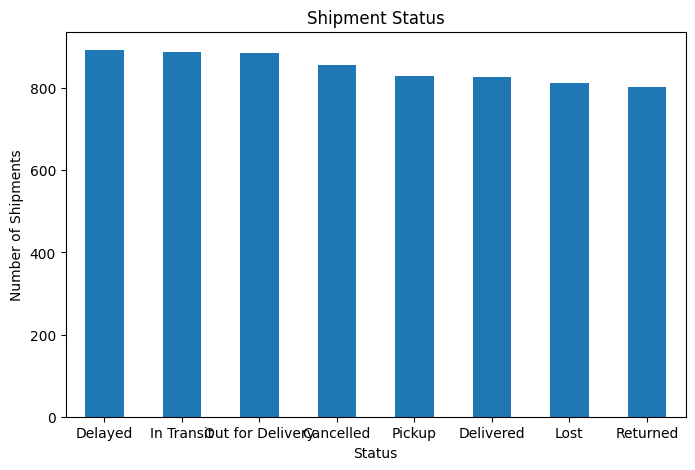

In [37]:
shipments["Delivery_Status"].value_counts().plot(kind="bar",figsize=(8,5))

plt.title("Shipment Status")
plt.xlabel("Status")
plt.ylabel("Number of Shipments")
plt.xticks(rotation=0)

plt.show()

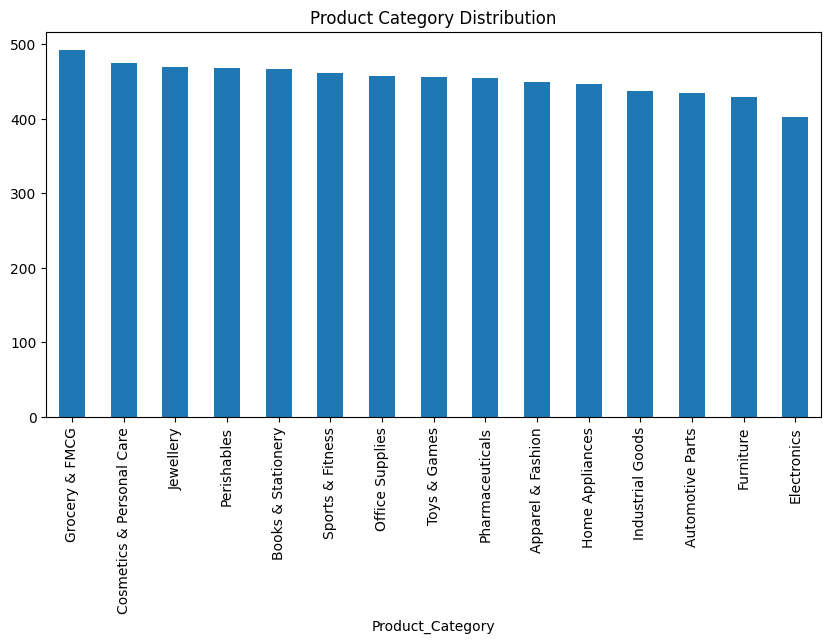

In [38]:
shipments["Product_Category"].value_counts().plot(kind="bar",figsize=(10,5))

plt.title("Product Category Distribution")

plt.show()

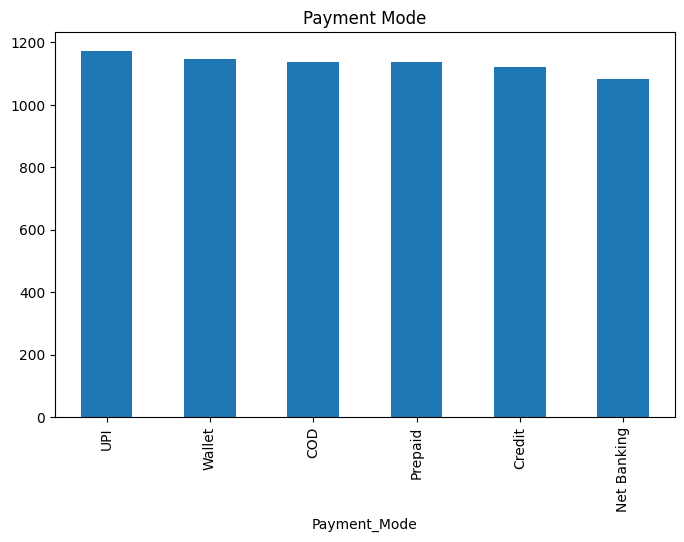

In [39]:
shipments["Payment_Mode"].value_counts().plot(kind="bar",figsize=(8,5))

plt.title("Payment Mode")

plt.show()

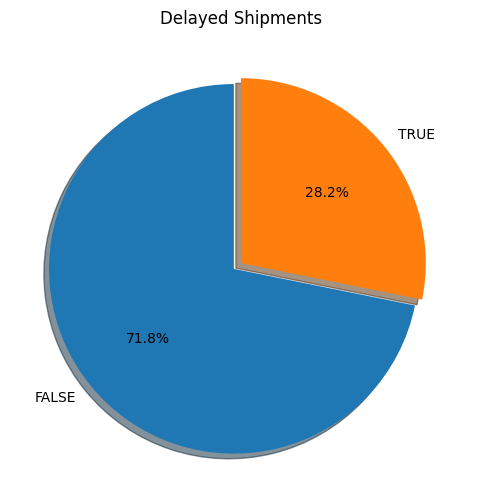

In [40]:
shipments["Is_Delayed"].value_counts().plot(
    kind="pie",
    figsize=(6, 6),
    autopct="%1.1f%%",      
    startangle=90,          
    explode=[0.05, 0],      
    shadow=True,
    ylabel=""               
)

plt.title("Delayed Shipments")
plt.show()

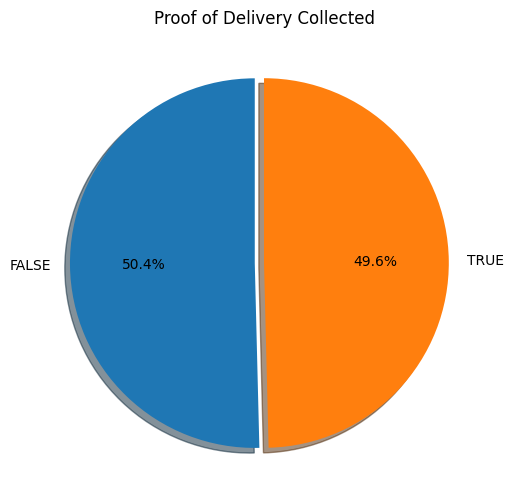

In [45]:
shipments["POD_Collected"].value_counts().plot(
    kind="pie",
    figsize=(6,6),
    autopct="%1.1f%%",      
    startangle=90,          
    explode=[0.05, 0],      
    shadow=True,
    ylabel=""
)

plt.title("Proof of Delivery Collected")

plt.show()

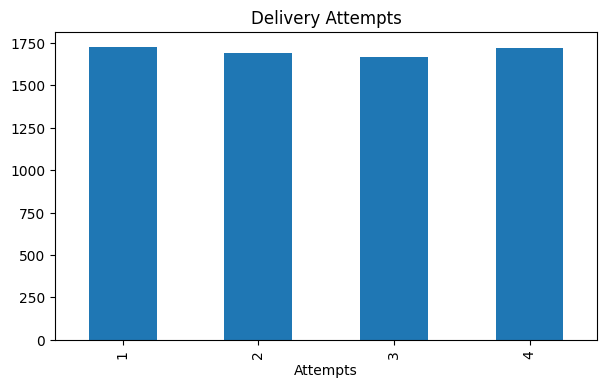

In [42]:
shipments["Attempts"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(7,4)
)

plt.title("Delivery Attempts")

plt.show()


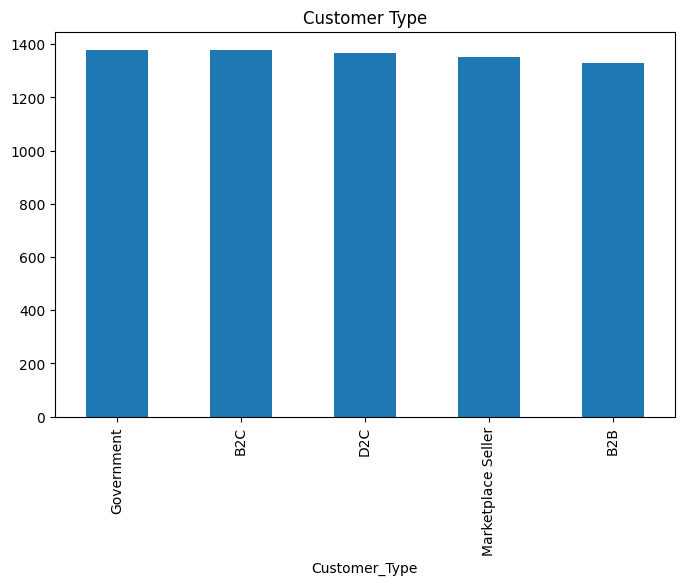

In [43]:
customers["Customer_Type"].value_counts().plot(kind='bar',figsize=(8,5))

plt.title("Customer Type")

plt.show()